In [4]:
%reload_ext autoreload
%autoreload 2

import brian2 as b2
import brian2hears as b2h
from brian2 import Hz, ms, kHz
import os
from analyze.report import draw_spikes_and_psth_bothside, draw_rate_vs_angle
import matplotlib.pyplot as plt
import numpy as np
import dill
from utils.custom_sounds import Tone, WhiteNoise, Click
from simulate.models.BrainstemModel.params import Parameters as params
from simulate.cochleas.ZilanyCochlea import run_repeated_sound_psth
from analyze.report import plot_sound, plot_rasterplot
from utils.anf_utils import load_anf_response, ZI_COC_KEY


2026-02-23 10:56:34,988 [INFO ]  

>>>>> start execution
✅ Using local cochlea package from: /Users/francescodesantis/Documents/repos/sound_localization_model/external/cochlea-1

              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.8.0
 Built: Jul 24 2025 05:26:03

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

✅ Using local cochlea package from: /Users/francescodesantis/Documents/repos/sound_localization_model/external/cochlea-1



How to cite *cochlea*:

Rudnicki M. and Hemmert W. (2009—). Cochlea: inner ear models in
Python.  https://github.com/mrkrd/cochlea/

@Misc{Rudnicki2009-Cochlea,
  author       = {Rudnicki, M. and Hemmert, W.},
  title        = {Cochlea: inner ear models in Python},
  year         = {2009--},
  howpublished = {https://github.com/mrkrd/cochlea},
  url          = {https://github.com/mrkrd/cochlea},
}



(<Figure size 600x400 with 1 Axes>,
 <Axes: xlabel='Time (ms)', ylabel='Amplitude'>)

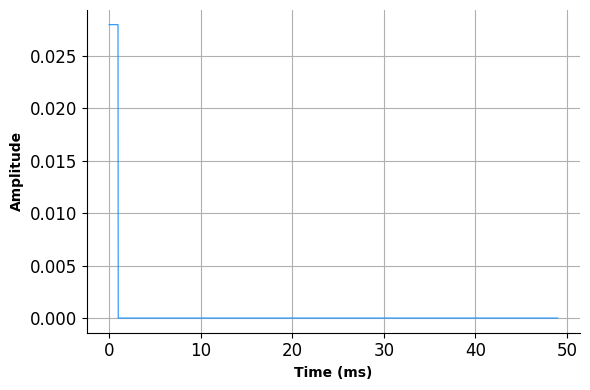

In [71]:
f = 500
level = 60 * b2h.dB
angle = 0
duration = 50 * b2.ms
ramp = 10
#sound = Tone(f * b2.Hz, duration=duration, level=level, ramp_ms=ramp, offset_silence_duration=50 * b2.ms)
#sound = WhiteNoise(duration=duration, level=level, ramp_ms=ramp, offset_silence_duration=50 * b2.ms)
sound = Click(duration=duration, click_duration=1* b2.ms, level=level)
plot_sound(sound.sound, color = 'dodgerblue')

In [72]:
p = params()
print(p.cochlea[ZI_COC_KEY]['cochlea_params'])

{'anf_num': (6, 2, 2), 'species': 'human', 'cohc': 1.0, 'cihc': 1.0, 'powerlaw': 'approximate', 'ffGn': False}


In [73]:
anf = load_anf_response(sound, 0, ZI_COC_KEY, p.cochlea)

2026-02-16 23:10:25,218 [INFO ]  Subject chosen: 0
2026-02-16 23:10:25,221 [INFO ]  [load_anf_response] Saved ANF not found. Regenerating...
2026-02-16 23:10:25,221 [INFO ]  [load_anf_response] Generating ANF for sound=<utils.custom_sounds.Click object at 0x377200e80>, angle=0, key=Zilany
2026-02-16 23:10:25,221 [INFO ]  [sound_to_spikes] Generating ANF spikes for angle=0 params={'hrtf_params': {'subj_number': 0, 'itd_remove_strategy': 'estimate_from_hrtf'}, 'cochlea_params': {'anf_num': (6, 2, 2), 'species': 'human', 'cohc': 1.0, 'cihc': 1.0, 'powerlaw': 'approximate', 'ffGn': False}, 'rng_seed': 42, 'omni_noise_level': 0}
2026-02-16 23:10:25,221 [DEBUG]  Generating spikes for sound=<utils.custom_sounds.Click object at 0x377200e80> angle=0 plot_spikes=False hrtf_params={'subj_number': 0, 'itd_remove_strategy': 'estimate_from_hrtf'}
2026-02-16 23:10:25,221 [DEBUG]  [sound_to_spikes] Running HRTF...
2026-02-16 23:10:25,221 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-16 

Avg firing rate: 59.24 Hz


(<Figure size 1500x800 with 3 Axes>,
 (<Axes: ylabel='CF [Hz]'>,
  <Axes: xlabel='Avg rate [Hz]'>,
  <Axes: xlabel='Time (ms)', ylabel='Rate [Hz]'>))

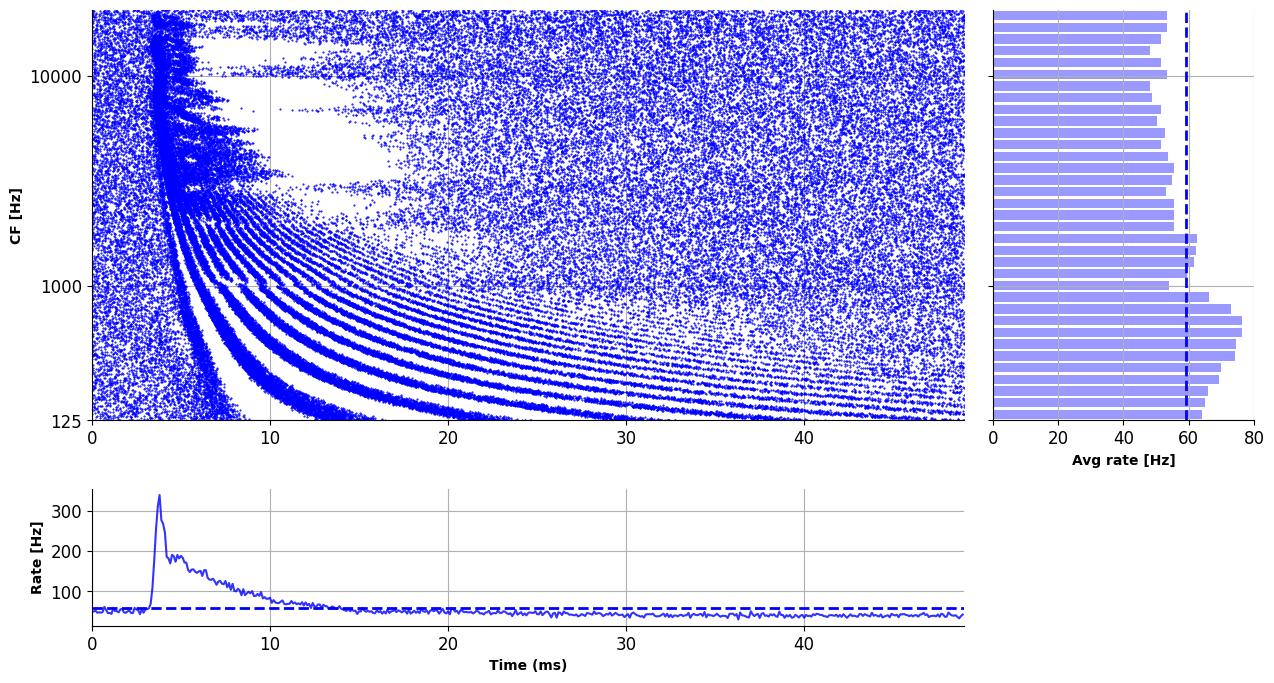

In [74]:
plot_rasterplot(
    spikes_series=anf.binaural_anf_spiketrain['L'],
    y_ax='cf_custom',
    f_ticks=[125, 1000, 10000],
    hist_rate=True,
    cf_bin_size=1000, #cells
    psth_bin_size=0.1, #ms
)

## Changing Zilany Parameters

In [9]:
p2 = params()
p2.cochlea[ZI_COC_KEY]['cochlea_params']['cohc'] = 0
print(p2.cochlea[ZI_COC_KEY]['cochlea_params'])

{'anf_num': (6, 2, 2), 'species': 'human', 'cohc': 0, 'cihc': 1.0, 'powerlaw': 'approximate', 'ffGn': False}


In [10]:
anf2 = load_anf_response(sound, 0, ZI_COC_KEY, p2.cochlea)

2026-02-12 13:03:57,566 [INFO ]  Subject chosen: 0
2026-02-12 13:03:57,568 [INFO ]  [load_anf_response] Saved ANF not found. Regenerating...
2026-02-12 13:03:57,568 [INFO ]  [load_anf_response] Generating ANF for sound=<utils.custom_sounds.Tone object at 0x30eb963a0>, angle=0, key=Zilany
2026-02-12 13:03:57,568 [INFO ]  [sound_to_spikes] Generating ANF spikes for angle=0 params={'hrtf_params': {'subj_number': 0, 'itd_remove_strategy': 'estimate_from_hrtf'}, 'cochlea_params': {'anf_num': (6, 2, 2), 'species': 'human', 'cohc': 0, 'cihc': 1.0, 'powerlaw': 'approximate', 'ffGn': False}, 'rng_seed': 42, 'omni_noise_level': 0}
2026-02-12 13:03:57,568 [DEBUG]  Generating spikes for sound=<utils.custom_sounds.Tone object at 0x30eb963a0> angle=0 plot_spikes=False hrtf_params={'subj_number': 0, 'itd_remove_strategy': 'estimate_from_hrtf'}
2026-02-12 13:03:57,568 [DEBUG]  [sound_to_spikes] Running HRTF...
2026-02-12 13:03:57,568 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-12 13:0

Avg firing rate: 54.65 Hz


(<Figure size 1500x800 with 3 Axes>,
 (<Axes: ylabel='CF [Hz]'>,
  <Axes: xlabel='Avg rate [Hz]'>,
  <Axes: xlabel='Time (ms)', ylabel='Rate [Hz]'>))

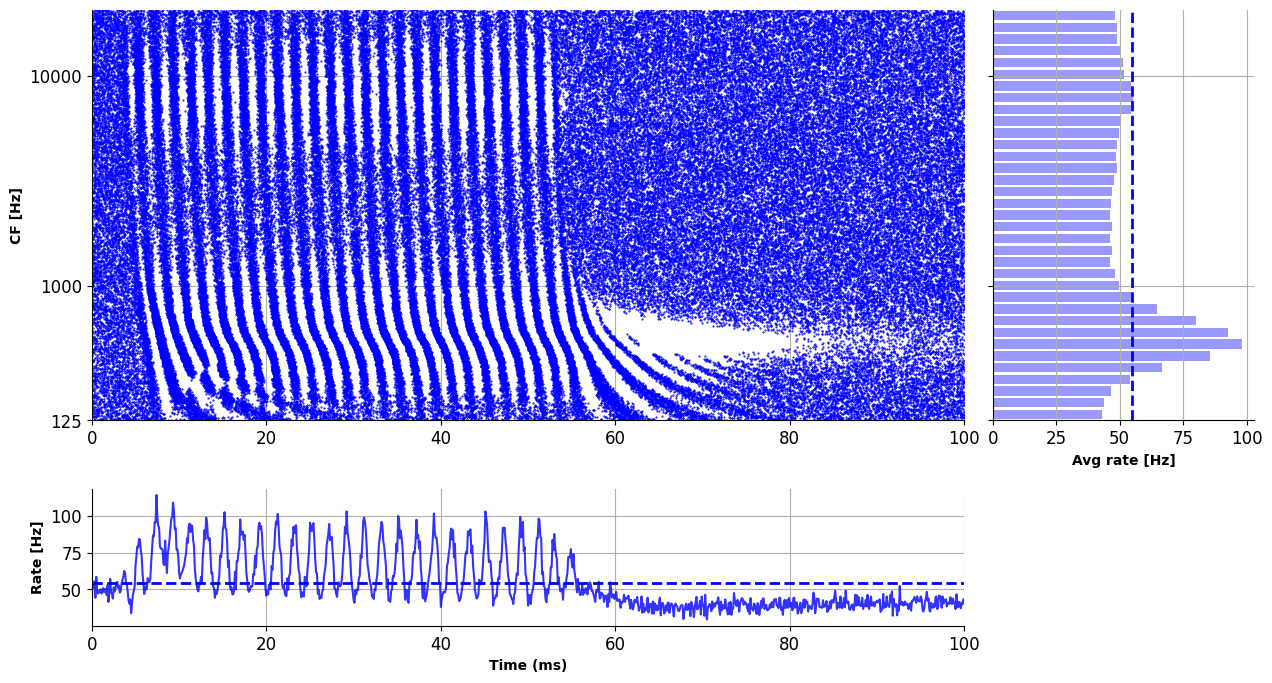

In [12]:
plot_rasterplot(
    spikes_series=anf2.binaural_anf_spiketrain['L'],
    y_ax='cf_custom',
    f_ticks=[125, 1000, 10000],
    hist_rate=True,
    cf_bin_size=1000, #cells
    psth_bin_size=0.1, #ms
)

In [13]:
p3 = params()
p3.cochlea[ZI_COC_KEY]['cochlea_params']['cihc'] = 0
print(p3.cochlea[ZI_COC_KEY]['cochlea_params'])

{'anf_num': (6, 2, 2), 'species': 'human', 'cohc': 1.0, 'cihc': 0, 'powerlaw': 'approximate', 'ffGn': False}


In [14]:
anf3 = load_anf_response(sound, 0, ZI_COC_KEY, p3.cochlea)

2026-02-12 13:10:21,114 [INFO ]  Subject chosen: 0
2026-02-12 13:10:21,116 [INFO ]  [load_anf_response] Saved ANF not found. Regenerating...
2026-02-12 13:10:21,116 [INFO ]  [load_anf_response] Generating ANF for sound=<utils.custom_sounds.Tone object at 0x30eb963a0>, angle=0, key=Zilany
2026-02-12 13:10:21,117 [INFO ]  [sound_to_spikes] Generating ANF spikes for angle=0 params={'hrtf_params': {'subj_number': 0, 'itd_remove_strategy': 'estimate_from_hrtf'}, 'cochlea_params': {'anf_num': (6, 2, 2), 'species': 'human', 'cohc': 1.0, 'cihc': 0, 'powerlaw': 'approximate', 'ffGn': False}, 'rng_seed': 42, 'omni_noise_level': 0}
2026-02-12 13:10:21,117 [DEBUG]  Generating spikes for sound=<utils.custom_sounds.Tone object at 0x30eb963a0> angle=0 plot_spikes=False hrtf_params={'subj_number': 0, 'itd_remove_strategy': 'estimate_from_hrtf'}
2026-02-12 13:10:21,117 [DEBUG]  [sound_to_spikes] Running HRTF...
2026-02-12 13:10:21,117 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2026-02-12 13:1

Avg firing rate: 45.96 Hz


(<Figure size 1500x800 with 3 Axes>,
 (<Axes: ylabel='CF [Hz]'>,
  <Axes: xlabel='Avg rate [Hz]'>,
  <Axes: xlabel='Time (ms)', ylabel='Rate [Hz]'>))

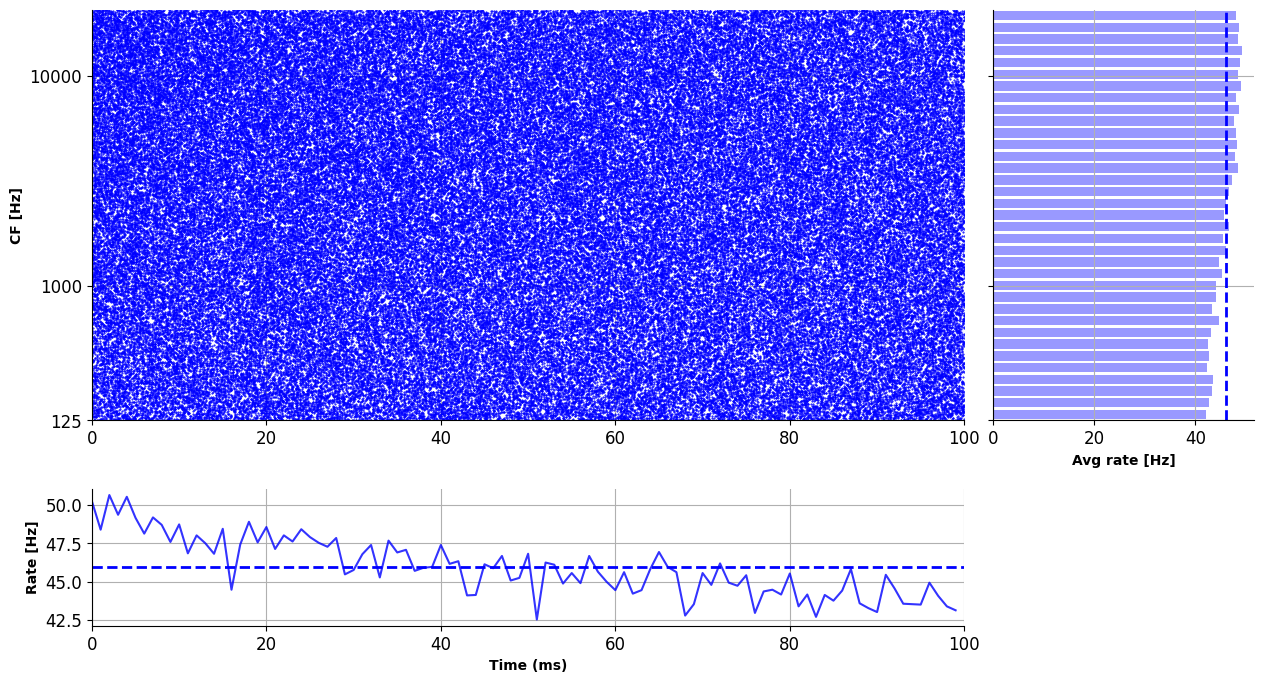

In [16]:
plot_rasterplot(
    spikes_series=anf3.binaural_anf_spiketrain['L'],
    y_ax='cf_custom',
    f_ticks=[125, 1000, 10000],
    hist_rate=True,
    cf_bin_size=1000, #cells
    psth_bin_size=1, #ms
)

## SINGLE FIBER PSTH

In [2]:
%reload_ext autoreload
%autoreload 2

import brian2 as b2
import brian2hears as b2h
from brian2 import Hz, ms, kHz
import os
from analyze.report import draw_spikes_and_psth_bothside, draw_rate_vs_angle
import matplotlib.pyplot as plt
import numpy as np
import dill
from utils.custom_sounds import Tone
from simulate.models.BrainstemModel.params import Parameters as params
from simulate.cochleas.ZilanyCochlea import run_repeated_sound_psth
from analyze.report import plot_sound, plot_rasterplot
from utils.anf_utils import load_anf_response, ZI_COC_KEY


2026-02-23 10:56:07,598 [INFO ]  

>>>>> start execution
✅ Using local cochlea package from: /Users/francescodesantis/Documents/repos/sound_localization_model/external/cochlea-1



How to cite *cochlea*:

Rudnicki M. and Hemmert W. (2009—). Cochlea: inner ear models in
Python.  https://github.com/mrkrd/cochlea/

@Misc{Rudnicki2009-Cochlea,
  author       = {Rudnicki, M. and Hemmert, W.},
  title        = {Cochlea: inner ear models in Python},
  year         = {2009--},
  howpublished = {https://github.com/mrkrd/cochlea},
  url          = {https://github.com/mrkrd/cochlea},
}




              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.8.0
 Built: Jul 24 2025 05:26:03

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

✅ Using local cochlea package from: /Users/francescodesantis/Documents/repos/sound_localization_model/external/cochlea-1


In [1]:
addresses = [
'/Users/francescodesantis/Library/CloudStorage/OneDrive-PolitecnicodiMilano/work/sound_localization/sl_results/zilany/',
'/Users/francescodesantis/Documents/repos/sound_localization_model/results/',
'/g100_work/EIRI_E_POLIM2/desa/sound_localization_model/results/',
]
results_dir = addresses[1]

In [18]:
level = 60 * b2h.dB
angle = 0
duration = 50 * b2.ms
ramp = 10
P = params()

for f in [500]:
    sound = Tone(f * b2.Hz, duration=duration, level=level, ramp_ms=ramp, offset_silence_duration=50 * b2.ms)

    run_repeated_sound_psth(
        sound=sound,
        n_reps=100,
        save_name= results_dir +f'ANF_{f}Hz_100rep.pic',
        params=P.cochlea[ZI_COC_KEY]
        )


Running repetitions:   0%|          | 0/100 [00:00<?, ?it/s]

Running repetitions: 100%|██████████| 100/100 [54:50<00:00, 32.90s/it]


2026-02-23 12:01:27,624 [INFO ]  [run_repeated_tone_psth] Saved spikes to /Users/francescodesantis/Documents/repos/sound_localization_model/results/ANF_500Hz_100rep.pic


In [19]:
# List directory contents
items = os.listdir(results_dir)
items = sorted(items)
for i, item in enumerate(items):
    print(i, item)

0 .DS_Store
1 ANF_1200Hz_100rep.pic
2 ANF_16000Hz_100rep.pic
3 ANF_4000Hz_100rep.pic
4 ANF_500Hz_100rep.pic
5 tone_0.5kHz_59dB&Zilany&subject_0.pic
6 tone_0.5kHz_59dB&Zilany&subject_0_LNTB.pic
7 tone_0.5kHz_59dB&Zilany&subject_0_LSO_exc_leading.pic
8 tone_0.5kHz_59dB&Zilany&subject_0_LSO_inh_leading.pic
9 tone_0.5kHz_59dB&Zilany&subject_1.pic
10 tone_0.5kHz_59dB&Zilany&subject_2.pic
11 tone_0.5kHz_59dB&Zilany&subject_3.pic
12 tone_0.5kHz_59dB&Zilany&subject_4.pic
13 tone_1.2kHz_59dB&Zilany&subject_0.pic
14 zz_old


In [20]:
file_name = items[4]
print(f"Loading file: {file_name}")
result_path = results_dir + file_name

with open(result_path, "rb") as file:
    result = dill.load(file, ignore=True)

Loading file: ANF_500Hz_100rep.pic


Selected neurons:
  Target CF      : 500.0 Hz
  Center idx     : 6843
  Index range    : [6843, 6843]
  CF range [Hz]  : 500.0 – 500.0
  # neurons used : 1


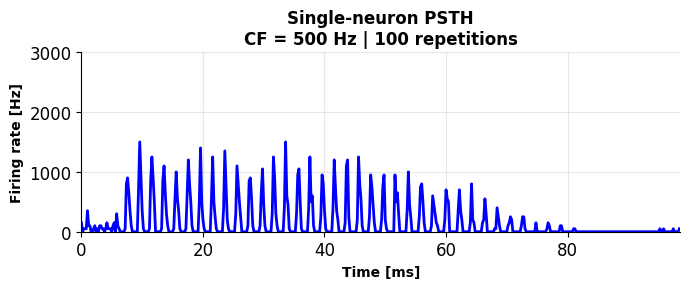

In [21]:
from analyze.report import plot_single_neuron_psth

plot_single_neuron_psth(
  spikes_file=result,
  target_cf_hz=500,
  ylim=(0, 3000),
  n_neighbors=0,
  bin_size=0.2,
  color = 'b',
  figsize=(7,3)
)

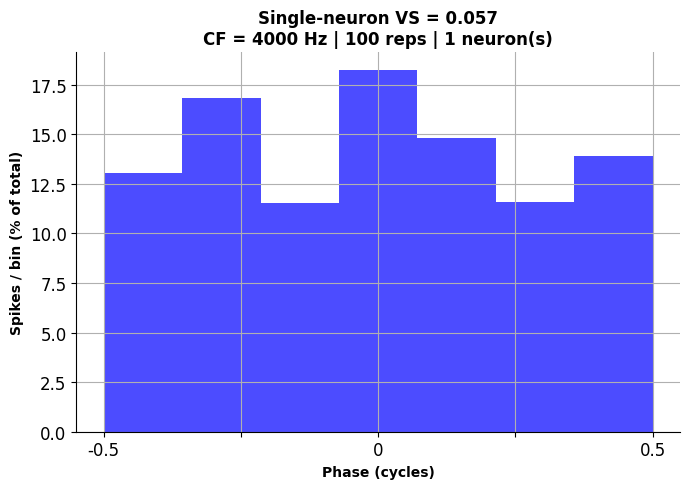

(0.056730141536331664, <Figure size 700x500 with 1 Axes>)

In [58]:
from analyze.report import calculate_single_neuron_vector_strength

calculate_single_neuron_vector_strength(
    spikes_file=result, 
    target_cf_hz=4000,
    n_neighbors=0,
    center_at_peak=True,
    )

Avg firing rate: 54.98 Hz


(<Figure size 1500x800 with 3 Axes>,
 (<Axes: ylabel='CF [Hz]'>,
  <Axes: xlabel='Avg rate [Hz]'>,
  <Axes: xlabel='Time (ms)', ylabel='Rate [Hz]'>))

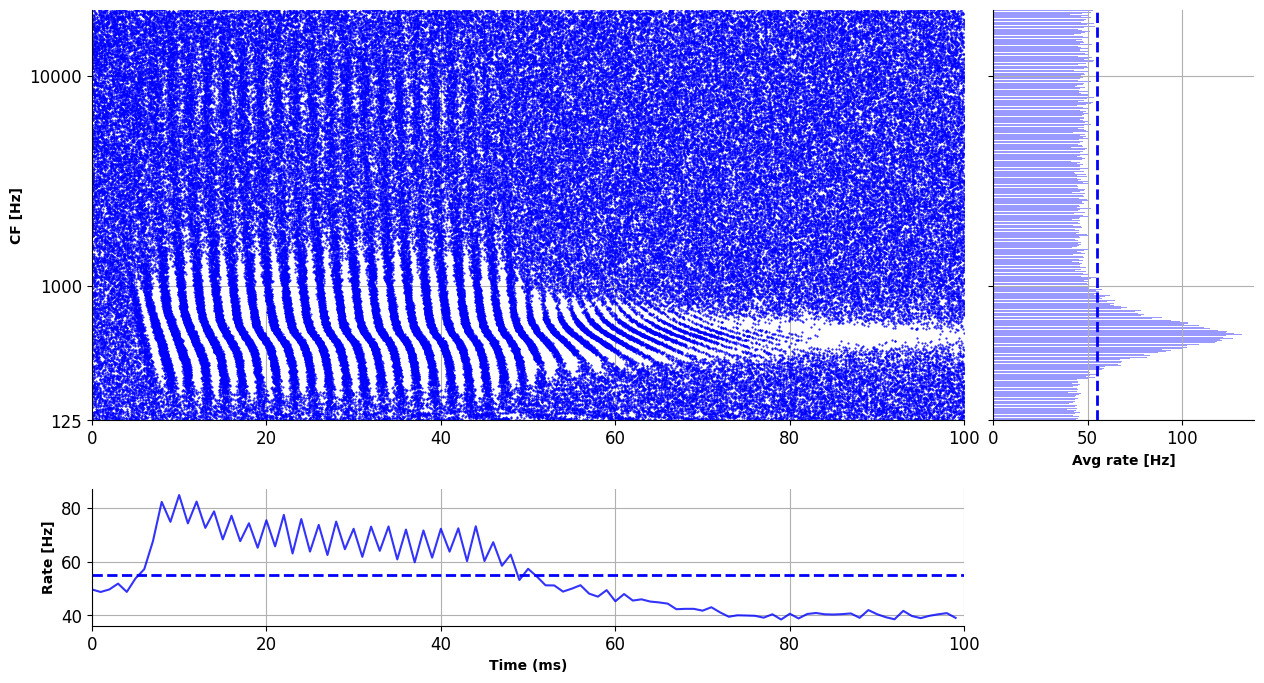

In [25]:
from analyze.report import draw_spikes_and_psth_bothside

plot_rasterplot(result[0])

In [1]:
from brian2 import Hz, kHz
from brian2hears import erbspace
from analyze.report import greenwood_cf_array

cf_erb = erbspace(125*Hz,20*kHz,35000)
cf_green = greenwood_cf_array(125,20000,35000)
fig, ax = plt.subplots(1, figsize = (10,5))
ax.plot(cf_erb, 'b', label = 'erbspace')
ax.plot(cf_green, 'g', label = 'greenwood')
ax.set_xlabel("ANFs id")
ax.set_ylabel("CFs [Hz]")
ax.set_title("ERBSPACE vs GREENWOOD mapping")

2026-03-01 15:36:42,805 [INFO ]  

>>>>> start execution
✅ Using local cochlea package from: /Users/francescodesantis/Documents/repos/sound_localization_model/external/cochlea-1



How to cite *cochlea*:

Rudnicki M. and Hemmert W. (2009—). Cochlea: inner ear models in
Python.  https://github.com/mrkrd/cochlea/

@Misc{Rudnicki2009-Cochlea,
  author       = {Rudnicki, M. and Hemmert, W.},
  title        = {Cochlea: inner ear models in Python},
  year         = {2009--},
  howpublished = {https://github.com/mrkrd/cochlea},
  url          = {https://github.com/mrkrd/cochlea},
}




              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.8.0
 Built: Jul 24 2025 05:26:03

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



NameError: name 'plt' is not defined